# Tutorial: Reproducing E001 Appendix Figures (A2-A6) with `crossmapy`

Audience:
- Researchers validating `crossmapy` against the Ecology 2015 appendix example (E001).

Prerequisites:
- `crossmapy` source tree (this repo)
- R with package `multispatialCCM` installed
- Python dependencies (`numpy`, `matplotlib`)

Learning goals:
- Reproduce Figure A2 style plots for low and high nitrogen treatments.
- Reproduce Figure A3/A5 style diagnostics.
- Reproduce Figure A4/A6 style lagged-dynamics plots.
- Compare `crossmapy` outputs with `multispatialCCM` and appendix text.

Execution policy:
- `ITERATIONS_MAIN` for A2 causal test (high precision).
- `ITERATIONS_DIAG` for auxiliary/diagnostic workflow (faster iteration).


## What can be reproduced from Appendix A (E001)

Using the provided E001 CSV files, this notebook reproduces:

1. Figure A2 style: `rho` vs `L` for both causal directions in `lvl0` and `lvl3`.
2. Figure A3 style diagnostics for `lvl0`.
3. Figure A4 style lagged dynamics for `lvl0`.
4. Figure A5 style diagnostics for `lvl3`.
5. Figure A6 style lagged dynamics for `lvl3`.

Appendix interpretation (paraphrased): even when A2-style CCM suggests directional forcing, diagnostics can reveal strong temporal structure and assumption violations; interpretation should remain cautious.


In [26]:
from __future__ import annotations

import csv
import json
import subprocess
import sys
import tempfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parents[1]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from crossmapy import CCM_boot, SSR_pred_boot, SSR_check_signal, ccmtest

DATA_DIR = ROOT /  "Spatial convergent cross mapping" / "3561957"
OUT_DIR = ROOT / "results" / "notebook_e001"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_TARGETS = {
    "lvl0": {"A_to_B": 0.614, "B_to_A": 0.004},
    "lvl3": {"A_to_B": 0.221, "B_to_A": 0.643},
}

DATA_DIR, OUT_DIR


(PosixPath('/Users/carloseduardoverasneves/Projects/crossmapy/Spatial convergent cross mapping/3561957'),
 PosixPath('/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001'))

In [27]:
@dataclass
class E001Data:
    name: str
    year: np.ndarray
    a_repens: np.ndarray
    s_scoparium: np.ndarray


def _find_header_row(path: Path) -> int:
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            norm = line.strip().strip('"').lower()
            if norm.startswith("index") and "agropyron" in norm:
                return i
    raise ValueError(f"Header not found in {path}")


def _to_float_or_nan(v: str) -> float:
    v = (v or "").strip()
    if (not v) or v.upper() == "NA":
        return float("nan")
    return float(v)


def load_e001(path: Path, name: str) -> E001Data:
    header = _find_header_row(path)
    years, a_vals, b_vals = [], [], []
    with path.open("r", encoding="utf-8") as f:
        for _ in range(header):
            next(f)
        reader = csv.DictReader(f)
        for row in reader:
            years.append(_to_float_or_nan(row.get("Year", "")))
            a_vals.append(_to_float_or_nan(row.get("Agropyron repens", "")))
            b_vals.append(_to_float_or_nan(row.get("Schizachyrium scoparium", "")))
    return E001Data(name, np.array(years), np.array(a_vals), np.array(b_vals))


lvl0 = load_e001(DATA_DIR / "e001_arssnlvl0.csv", "lvl0")
lvl3 = load_e001(DATA_DIR / "e001_arssnlvl3.csv", "lvl3")
print("lvl0 shape:", lvl0.a_repens.shape, "nan:", np.isnan(lvl0.a_repens).sum())
print("lvl3 shape:", lvl3.a_repens.shape, "nan:", np.isnan(lvl3.a_repens).sum())


lvl0 shape: (995,) nan: 59
lvl3 shape: (995,) nan: 59


In [28]:
def choose_E(series: np.ndarray, max_e: int = 16):
    rho_by_e = {}
    for e in range(2, max_e + 1):
        rho_by_e[e] = float(SSR_pred_boot(A=series, E=e, tau=1, predstep=1)["rho"])
    valid = {k: v for k, v in rho_by_e.items() if np.isfinite(v)}
    return max(valid, key=valid.get), rho_by_e
def run_python_ccm(A, B, e_a, e_b, iterations=100, seed=2718):
    np.random.seed(seed)
    ab = CCM_boot(A=A, B=B, E=e_a, tau=1, iterations=iterations)
    np.random.seed(seed)
    ba = CCM_boot(A=B, B=A, E=e_b, tau=1, iterations=iterations)
    p = ccmtest(ab, ba)
    return {
        "ab": ab,
        "ba": ba,
        "p_a_to_b": float(p["pval_a_cause_b"]),
        "p_b_to_a": float(p["pval_b_cause_a"]),
    }
def _serialize_for_r(A, B, path: Path):
    with path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["A", "B"])
        for a, b in zip(A, B):
            w.writerow(["" if np.isnan(a) else f"{a:.17g}", "" if np.isnan(b) else f"{b:.17g}"])
def run_r_ccm(A, B, e_a, e_b, iterations=100, seed=2718):
    with tempfile.NamedTemporaryFile("w", suffix=".csv", delete=False, encoding="utf-8") as tmp:
        tmp_path = Path(tmp.name)
    _serialize_for_r(A, B, tmp_path)
    r_code = r'''args <- commandArgs(trailingOnly=TRUE)
path <- args[[1]]
e_a <- as.integer(args[[2]])
e_b <- as.integer(args[[3]])
it <- as.integer(args[[4]])
seed <- as.integer(args[[5]])
set.seed(seed)
suppressPackageStartupMessages(library(multispatialCCM))
d <- read.csv(path)
A <- d$A
B <- d$B
ab <- CCM_boot(A, B, E=e_a, tau=1, iterations=it)
ba <- CCM_boot(B, A, E=e_b, tau=1, iterations=it)
pv <- ccmtest(ab, ba)
pv_a <- if (is.list(pv)) pv$pval_a_cause_b else unname(pv["pval_a_cause_b"])
pv_b <- if (is.list(pv)) pv$pval_b_cause_a else unname(pv["pval_b_cause_a"])
cat("P_A_TO_B=", pv_a, "\n", sep="")
cat("P_B_TO_A=", pv_b, "\n", sep="")
cat("L_AB=", paste(ab$Lobs, collapse=","), "\n", sep="")
cat("RHO_AB=", paste(ab$rho, collapse=","), "\n", sep="")
cat("L_BA=", paste(ba$Lobs, collapse=","), "\n", sep="")
cat("RHO_BA=", paste(ba$rho, collapse=","), "\n", sep="")'''
    proc = subprocess.run(["Rscript", "-e", r_code, str(tmp_path), str(e_a), str(e_b), str(iterations), str(seed)], capture_output=True, text=True, check=False)
    tmp_path.unlink(missing_ok=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr)
    vals = {}
    for line in proc.stdout.splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            vals[k.strip()] = v.strip()
    def parse_arr(s):
        out = []
        for t in s.split(","):
            t = t.strip()
            out.append(float("nan") if (not t or t.upper() == "NA") else float(t))
        return np.array(out, dtype=float)
    return {
        "p_a_to_b": float(vals["P_A_TO_B"]),
        "p_b_to_a": float(vals["P_B_TO_A"]),
        "L_ab": parse_arr(vals["L_AB"]),
        "rho_ab": parse_arr(vals["RHO_AB"]),
        "L_ba": parse_arr(vals["L_BA"]),
        "rho_ba": parse_arr(vals["RHO_BA"]),
    }


## Execution controls and caches

Run only the block you need:
- **A2 block**: expensive, uses `ITERATIONS_MAIN`.
- **Diagnostics block**: faster, uses `ITERATIONS_DIAG` and does not require R.


In [ ]:
ITERATIONS_MAIN = 1000
ITERATIONS_DIAG = 100
SEED = 2718

# independent caches
results_main = {}
results_diag = {}


### A2 only - compute main CCM results (Python + R)

This block computes only what is needed for A2-style plots and p-values.


In [ ]:
def compute_main_results(iterations=ITERATIONS_MAIN, seed=SEED):
    out = {}
    for scenario in [lvl0, lvl3]:
        e_a, e_scan_a = choose_E(scenario.a_repens, max_e=16)
        e_b, e_scan_b = choose_E(scenario.s_scoparium, max_e=16)
        py = run_python_ccm(scenario.a_repens, scenario.s_scoparium, e_a, e_b, iterations=iterations, seed=seed)
        rb = run_r_ccm(scenario.a_repens, scenario.s_scoparium, e_a, e_b, iterations=iterations, seed=seed)
        out[scenario.name] = {
            'E_A': e_a,
            'E_B': e_b,
            'E_scan_A': e_scan_a,
            'E_scan_B': e_scan_b,
            'python': py,
            'r': rb,
        }
    return out

# run only when needed
results_main = compute_main_results()
{k: {'E_A': v['E_A'], 'E_B': v['E_B'], 'py_p': (v['python']['p_a_to_b'], v['python']['p_b_to_a']), 'r_p': (v['r']['p_a_to_b'], v['r']['p_b_to_a'])} for k,v in results_main.items()}


### Diagnostics only - compute fast diagnostic context (no R baseline)

This block computes embedding choices for diagnostics and lagged plots.


In [ ]:
def compute_diag_results(seed=SEED):
    np.random.seed(seed)
    out = {}
    for scenario in [lvl0, lvl3]:
        e_a, e_scan_a = choose_E(scenario.a_repens, max_e=16)
        e_b, e_scan_b = choose_E(scenario.s_scoparium, max_e=16)
        out[scenario.name] = {
            'E_A': e_a,
            'E_B': e_b,
            'E_scan_A': e_scan_a,
            'E_scan_B': e_scan_b,
        }
    return out

results_diag = compute_diag_results()
results_diag


## Figure A2 style reproduction

The next cell reproduces the A2-style `rho` vs `L` plots for both treatments, with Python and R overlays and appendix p-values.


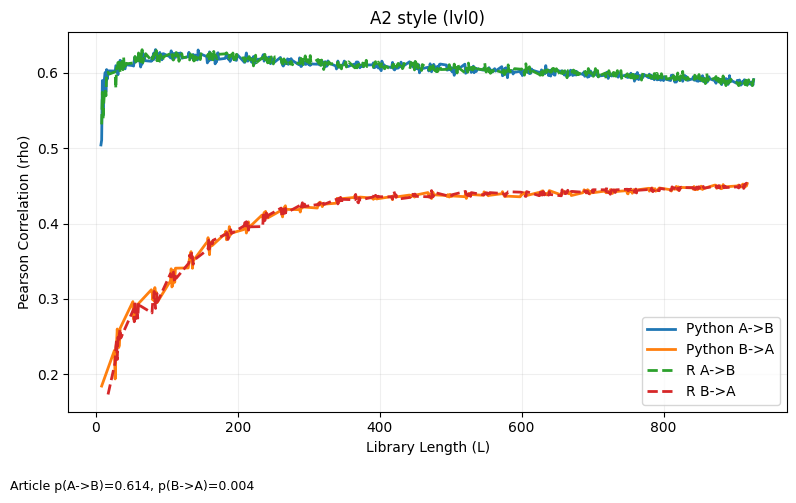

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A2_style_lvl0.png


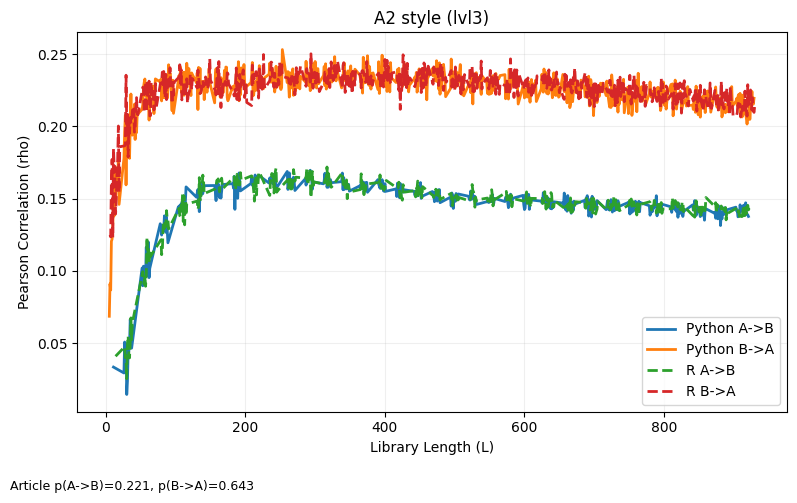

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A2_style_lvl3.png


In [22]:
def plot_a2_style(key):
    v = results_main[key]
    py, rb = v["python"], v["r"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(py["ab"]["Lobs"], py["ab"]["rho"], lw=2, label="Python A->B")
    ax.plot(py["ba"]["Lobs"], py["ba"]["rho"], lw=2, label="Python B->A")
    ax.plot(rb["L_ab"], rb["rho_ab"], "--", lw=2, label="R A->B")
    ax.plot(rb["L_ba"], rb["rho_ba"], "--", lw=2, label="R B->A")
    ax.set_title(f"A2 style ({key})")
    ax.set_xlabel("Library Length (L)")
    ax.set_ylabel("Pearson Correlation (rho)")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.text(0.01, 0.01, f"Article p(A->B)={ARTICLE_TARGETS[key]['A_to_B']:.3f}, p(B->A)={ARTICLE_TARGETS[key]['B_to_A']:.3f}", fontsize=9)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    out = OUT_DIR / f"A2_style_{key}.png"
    fig.savefig(out, dpi=140)
    plt.show()
    print(out)

plot_a2_style("lvl0")
plot_a2_style("lvl3")


if not results_main:
    raise RuntimeError("results_main is empty. Run the A2 compute block first.")


## Figure A3 and A5 style diagnostics

Top row: `rho` vs embedding dimension `E`.
Bottom row: `rho` vs prediction steps.


Diagnostic runtime note:

- A3/A5 diagnostics here are computed with simplex/signal routines and are independent of `ITERATIONS_MAIN`.
- Keep `ITERATIONS_DIAG` as a fast-workflow control for additional exploratory blocks.
- Use `ITERATIONS_MAIN=1000` only for A2 causal curves and p-values.


Error - too few records to test E = 6, tau = 1, and predstep = 23
Error - too few records to test E = 6, tau = 1, and predstep = 24
Error - too few records to test E = 6, tau = 1, and predstep = 25
Error - too few records to test E = 6, tau = 1, and predstep = 25
Error - too few records to test E = 15, tau = 1, and predstep = 14
Error - too few records to test E = 15, tau = 1, and predstep = 15
Error - too few records to test E = 15, tau = 1, and predstep = 16
Error - too few records to test E = 15, tau = 1, and predstep = 17
Error - too few records to test E = 15, tau = 1, and predstep = 18
Error - too few records to test E = 15, tau = 1, and predstep = 19
Error - too few records to test E = 15, tau = 1, and predstep = 20
Error - too few records to test E = 15, tau = 1, and predstep = 21
Error - too few records to test E = 15, tau = 1, and predstep = 22
Error - too few records to test E = 15, tau = 1, and predstep = 23
Error - too few records to test E = 15, tau = 1, and predstep = 24

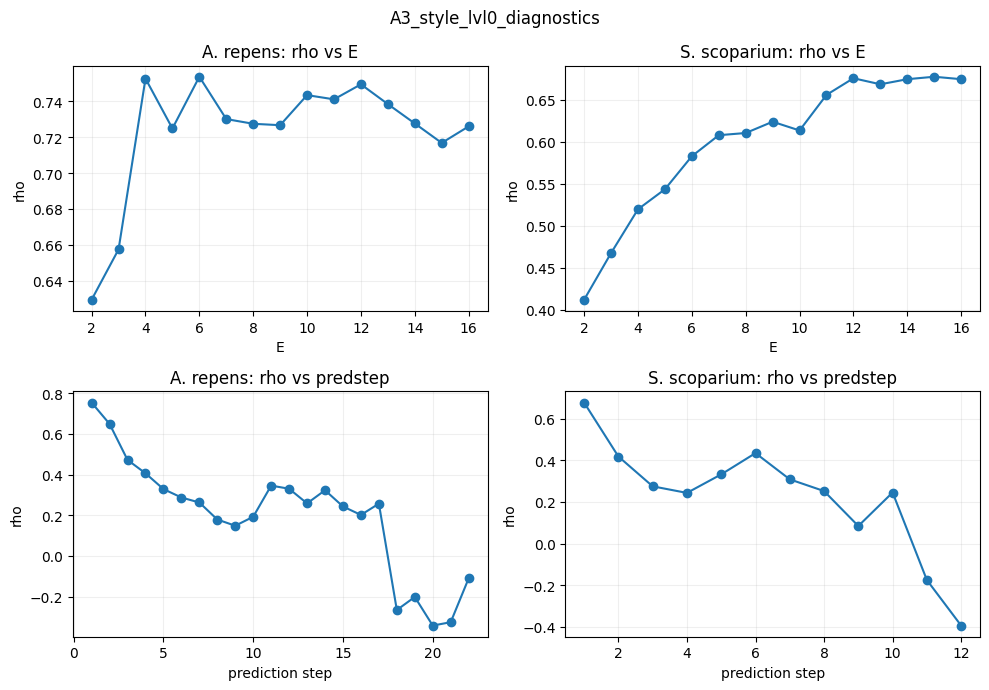

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A3_style_lvl0_diagnostics.png
Error - too few records to test E = 12, tau = 1, and predstep = 17
Error - too few records to test E = 12, tau = 1, and predstep = 18
Error - too few records to test E = 12, tau = 1, and predstep = 19
Error - too few records to test E = 12, tau = 1, and predstep = 20
Error - too few records to test E = 12, tau = 1, and predstep = 21
Error - too few records to test E = 12, tau = 1, and predstep = 22
Error - too few records to test E = 12, tau = 1, and predstep = 23
Error - too few records to test E = 12, tau = 1, and predstep = 24
Error - too few records to test E = 12, tau = 1, and predstep = 25
Error - too few records to test E = 12, tau = 1, and predstep = 25


/Users/carloseduardoverasneves/Projects/crossmapy/python/crossmapy/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/carloseduardoverasneves/Projects/crossmapy/python/crossmapy/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Error - too few records to test E = 4, tau = 1, and predstep = 25
Error - too few records to test E = 4, tau = 1, and predstep = 25


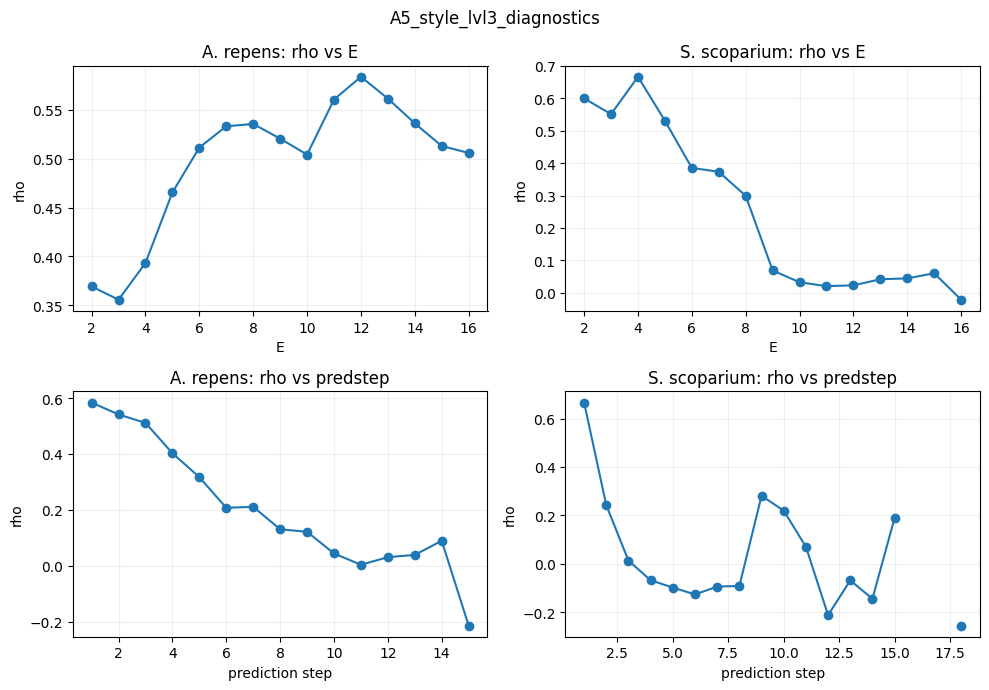

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A5_style_lvl3_diagnostics.png


In [23]:
def max_valid_predstep(series, E, tau=1):
    probe = SSR_pred_boot(A=series, E=E, tau=tau, predstep=1)
    lengthacceptable = int(probe["plengthacceptablelib"])
    # SSR_pred_boot requires: tau*(E+1)+predstep < lengthacceptable
    max_step = lengthacceptable - (tau * (E + 1)) - 1
    return max(1, max_step)


def diagnostic_curves(series, e_selected, max_e=16, predsteps=range(1, 26)):
    e_vals = np.array(list(range(2, max_e + 1)))
    e_rho = np.array([float(SSR_pred_boot(A=series, E=e, tau=1, predstep=1)["rho"]) for e in e_vals])

    max_step = max_valid_predstep(series, e_selected, tau=1)
    predsteps = np.array([p for p in predsteps if p <= max_step], dtype=int)
    sig = SSR_check_signal(A=series, E=e_selected, tau=1, predsteplist=predsteps)
    pred = np.asarray(sig["predatout"], dtype=float)
    return e_vals, e_rho, pred[:,0], pred[:,1], max_step


def plot_diag(data, e_a, e_b, label):
    eA_x, eA_y, pA_x, pA_y, max_a = diagnostic_curves(data.a_repens, e_a)
    eB_x, eB_y, pB_x, pB_y, max_b = diagnostic_curves(data.s_scoparium, e_b)
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes[0,0].plot(eA_x, eA_y, marker='o'); axes[0,0].set_title('A. repens: rho vs E')
    axes[0,1].plot(eB_x, eB_y, marker='o'); axes[0,1].set_title('S. scoparium: rho vs E')
    axes[1,0].plot(pA_x, pA_y, marker='o'); axes[1,0].set_title(f'A. repens: rho vs predstep (max={max_a})')
    axes[1,1].plot(pB_x, pB_y, marker='o'); axes[1,1].set_title(f'S. scoparium: rho vs predstep (max={max_b})')
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.set_ylabel('rho')
    axes[0,0].set_xlabel('E'); axes[0,1].set_xlabel('E')
    axes[1,0].set_xlabel('prediction step'); axes[1,1].set_xlabel('prediction step')
    fig.suptitle(label)
    fig.tight_layout()
    out = OUT_DIR / f"{label.replace(' ','_')}.png"
    fig.savefig(out, dpi=140)
    plt.show()
    print(out)

plot_diag(lvl0, results_diag['lvl0']['E_A'], results_diag['lvl0']['E_B'], 'A3_style_lvl0_diagnostics')
plot_diag(lvl3, results_diag['lvl3']['E_A'], results_diag['lvl3']['E_B'], 'A5_style_lvl3_diagnostics')



if not results_diag:
    raise RuntimeError("results_diag is empty. Run the diagnostics compute block first.")


## Figure A4 and A6 style lagged dynamics

Scatter of `t0` vs `t1` colored by year, for both species.


/var/folders/qd/l204x4bs3c15lv3hp2z4pn480000gn/T/ipykernel_93580/621772917.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


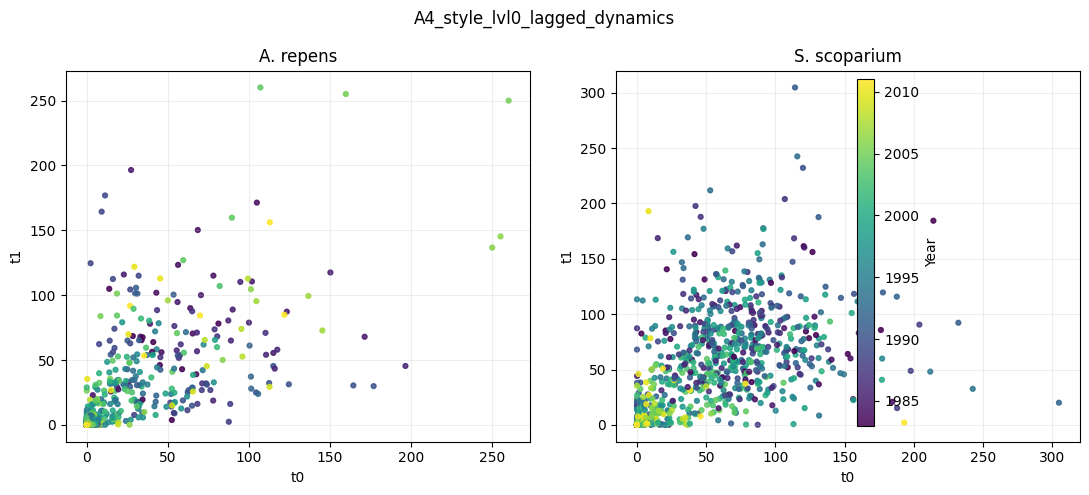

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A4_style_lvl0_lagged_dynamics.png


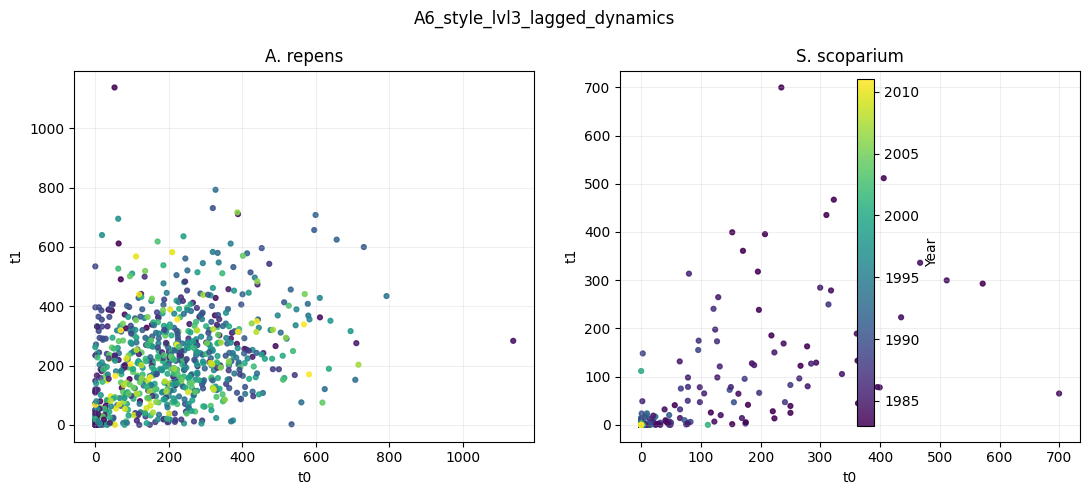

/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/A6_style_lvl3_lagged_dynamics.png


In [24]:
def lagged_pairs(series, year):
    t0, t1, yc = [], [], []
    for i in range(len(series) - 1):
        if np.isfinite(series[i]) and np.isfinite(series[i+1]) and np.isfinite(year[i+1]):
            t0.append(series[i]); t1.append(series[i+1]); yc.append(year[i+1])
    return np.array(t0), np.array(t1), np.array(yc)


def plot_lagged(data, label):
    a0, a1, ay = lagged_pairs(data.a_repens, data.year)
    b0, b1, by = lagged_pairs(data.s_scoparium, data.year)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].scatter(a0, a1, c=ay, cmap='viridis', s=12, alpha=0.85)
    axes[0].set_title('A. repens'); axes[0].set_xlabel('t0'); axes[0].set_ylabel('t1'); axes[0].grid(alpha=0.2)
    sc = axes[1].scatter(b0, b1, c=by, cmap='viridis', s=12, alpha=0.85)
    axes[1].set_title('S. scoparium'); axes[1].set_xlabel('t0'); axes[1].set_ylabel('t1'); axes[1].grid(alpha=0.2)
    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label('Year')
    fig.suptitle(label)
    fig.tight_layout()
    out = OUT_DIR / f"{label.replace(' ','_')}.png"
    fig.savefig(out, dpi=140)
    plt.show()
    print(out)

plot_lagged(lvl0, 'A4_style_lvl0_lagged_dynamics')
plot_lagged(lvl3, 'A6_style_lvl3_lagged_dynamics')


## Interpretation aligned with the appendix

- A2-style CCM curves can suggest directional forcing.
- A3/A5 diagnostics can still show problematic conditions (for example, non-declining predictability with longer prediction distance).
- A4/A6 lagged dynamics help explain these issues via temporal structure and regime shifts.

Conclusion for E001 stays consistent with Appendix A: diagnostics indicate caution, and naive CCM interpretation should not be trusted without these checks.


In [25]:
summary = {
    "iterations_main": ITERATIONS_MAIN,
    "iterations_diag": ITERATIONS_DIAG,
    "seed": SEED,
    "scenarios": {}
}

scenario_keys = sorted(set(list(results_main.keys()) + list(results_diag.keys())))
for k in scenario_keys:
    entry = {}
    if k in results_diag:
        entry["E_A"] = int(results_diag[k]["E_A"])
        entry["E_B"] = int(results_diag[k]["E_B"])
    if k in results_main:
        entry["python_p_a_to_b"] = float(results_main[k]["python"]["p_a_to_b"])
        entry["python_p_b_to_a"] = float(results_main[k]["python"]["p_b_to_a"])
        entry["r_p_a_to_b"] = float(results_main[k]["r"]["p_a_to_b"])
        entry["r_p_b_to_a"] = float(results_main[k]["r"]["p_b_to_a"])
    entry["article_p_a_to_b"] = float(ARTICLE_TARGETS[k]["A_to_B"])
    entry["article_p_b_to_a"] = float(ARTICLE_TARGETS[k]["B_to_A"])
    summary["scenarios"][k] = entry

out = OUT_DIR / "notebook_summary_e001.json"
out.write_text(json.dumps(summary, indent=2), encoding="utf-8")
out


PosixPath('/Users/carloseduardoverasneves/Projects/crossmapy/results/notebook_e001/notebook_summary_e001.json')